## HW 9 Kelper's Laws

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from scipy.optimize import curve_fit

In [19]:
solar_system = pd.read_csv("solar_system.csv")
solar_system

,Attribute,Mercury,Venus,Earth,Moon,Mars,Jupiter,Saturn,Uranus,Neptune,Pluto
0,Mass (10^24kg),0.330,4.87,5.97,0.073,0.642,1898,568,86.8,102,0.0130
1,Diameter (km),4879,12104,12756,3475,6792,142984,120536,51118,49528,2376
2,Density (kg/m^3),5429,5243,5514,3340,3934,1326,687,1270,1638,1850
3,Gravity (m/s^2),3.7,8.9,9.8,1.6,3.7,23.1,9.0,8.7,11.0,0.7
4,Escape Velocity (km/s),4.3,10.4,11.2,2.4,5.0,59.5,35.5,21.3,23.5,1.3
5,Rotation Period (hours),1407.6,-5832.5,23.9,655.7,24.6,9.9,10.7,-17.2,16.1,-153.3
6,Length of Day (hours),4222.6,2802.0,24.0,708.7,24.7,9.9,10.7,17.2,16.1,153.3
7,Distance from Sun (10^6 km),57.9,108.2,149.6,0.384,228.0,778.5,1432.0,2867.0,4515.0,5906.4
8,Perihelion (10^6 km),46.0,107.5,147.1,0.363,206.7,740.6,1357.6,2732.7,4471.1,4436.8
9,Aphelion (10^6 km),69.8,108.9,152.1,0.406,249.3,816.4,1506.5,3001.4,4558.9,7375.9


In [20]:
print(f"Data Shape: {solar_system.shape} | Number of Rows: {solar_system.shape[0]} | Number of Columns: {solar_system.shape[1]}")
print(f"Column Names: {solar_system.columns} | Row Names: \n{solar_system["Attribute"]}")
print("First Five Rows:")
solar_system.head()

Data Shape: (20, 11) | Number of Rows: 20 | Number of Columns: 11
Column Names: Index(['Attribute', 'Mercury', 'Venus', 'Earth', 'Moon', 'Mars', 'Jupiter',
       'Saturn', 'Uranus', 'Neptune', 'Pluto'],
      dtype='object') | Row Names: 
0                  Mass (10^24kg)
1                   Diameter (km)
2                Density (kg/m^3)
3                 Gravity (m/s^2)
4          Escape Velocity (km/s)
5         Rotation Period (hours)
6           Length of Day (hours)
7     Distance from Sun (10^6 km)
8            Perihelion (10^6 km)
9              Aphelion (10^6 km)
10          Orbital Period (days)
11        Orbital Velocity (km/s)
12      Orbital Inclination (deg)
13           Orbital Eccentricity
14       Obliquity to Orbit (deg)
15           Mean Temperature (C)
16        Surface Pressure (bars)
17                Number of Moons
18                   Ring System?
19         Global Magnetic Field?
Name: Attribute, dtype: object
First Five Rows:


,Attribute,Mercury,Venus,Earth,Moon,Mars,Jupiter,Saturn,Uranus,Neptune,Pluto
0,Mass (10^24kg),0.330,4.87,5.97,0.073,0.642,1898,568,86.8,102,0.0130
1,Diameter (km),4879,12104,12756,3475,6792,142984,120536,51118,49528,2376
2,Density (kg/m^3),5429,5243,5514,3340,3934,1326,687,1270,1638,1850
3,Gravity (m/s^2),3.7,8.9,9.8,1.6,3.7,23.1,9.0,8.7,11.0,0.7
4,Escape Velocity (km/s),4.3,10.4,11.2,2.4,5.0,59.5,35.5,21.3,23.5,1.3


In [21]:
print("Last Five Rows:")
solar_system.tail()

Last Five Rows:


,Attribute,Mercury,Venus,Earth,Moon,Mars,Jupiter,Saturn,Uranus,Neptune,Pluto
15,Mean Temperature (C),167,464,15,-20,-65,-110,-140,-195,-200,-225
16,Surface Pressure (bars),0,92,1,0,0.01,Unknown,Unknown,Unknown,Unknown,0.00001
17,Number of Moons,0,0,1,0,2,95,274,28,16,5
18,Ring System?,No,No,No,No,No,Yes,Yes,Yes,Yes,No
19,Global Magnetic Field?,Yes,No,Yes,No,No,Yes,Yes,Yes,Yes,Unknown


In [22]:
# Extractions
# Orbital Period index 10, Perihelion index 8, Aphelion index 9
orbital_period = solar_system.iloc[10, 1:].astype(float)
# kept getting error when I tried to index just the row, like [10], seems I need to slice because the first row is just an attribute and doesn't count as something to convert
perihelion = solar_system.iloc[8, 1:].astype(float)
aphelion = solar_system.iloc[9, 1:].astype(float)

print(f"Orbital Period: \n{orbital_period}")
print(f"Perihelion: \n{perihelion}")
print(f"Aphelion: \n{aphelion}")

Orbital Period: 
Mercury       88.0
Venus        224.7
Earth        365.2
Moon          27.3
Mars         687.0
Jupiter     4331.0
Saturn     10747.0
Uranus     30589.0
Neptune    59800.0
Pluto      90560.0
Name: 10, dtype: float64
Perihelion: 
Mercury      46.000
Venus       107.500
Earth       147.100
Moon          0.363
Mars        206.700
Jupiter     740.600
Saturn     1357.600
Uranus     2732.700
Neptune    4471.100
Pluto      4436.800
Name: 8, dtype: float64
Aphelion: 
Mercury      69.800
Venus       108.900
Earth       152.100
Moon          0.406
Mars        249.300
Jupiter     816.400
Saturn     1506.500
Uranus     3001.400
Neptune    4558.900
Pluto      7375.900
Name: 9, dtype: float64


### Definitions: 
#### Perihelion: point along a planet/body's orbit that is closest to its star (at one of the two foci).
#### Apehelion: point along a planet/body's orbit that is closest to its star (again which is at one of the two foci)
Note: Perihelion and Apehelion typically used for ellipitical orbit (thank you kepler) as circular orbits would have sun at the center (only foci, not two) and same distance at all points along orbit.

#### Semi-Major Axis: half of the major axis (aka max diameter) for an elliptical orbit. If you consider elliptical orbits as having a radius like a circular one (circular radius is constant everywhere), the semi major axis is the maximum. Typically along either semi-major axis lies the perihelion on one end and the aphelion on the other (depending on which of the two foci the sun/ respective star) is. 

In [23]:
semi_major_axis = (perihelion + aphelion) / 2

In [24]:
# adding Semi_Major Axis:
# need to add it to the attributes list because otherwise it will not have the same shape as the rest of the data and will give me an error almost guaranteed
# .name is apparently how i do so
semi_major_axis.name = "Semi-major Axis (AU)"

In [25]:
# expect 21 rows now
new_row = pd.Series(
    ["Semi-major Axis (AU)", *semi_major_axis.values],
    index=solar_system.columns
)

In [26]:
solar_system = pd.concat(
    [solar_system, new_row.to_frame().T],
    ignore_index=True
) # pls have 21 rows and not have shape 30 by 12 (don't ask lol)
print(f"Data Shape: {solar_system.shape} | Number of Rows: {solar_system.shape[0]} | Number of Columns: {solar_system.shape[1]}")

Data Shape: (21, 11) | Number of Rows: 21 | Number of Columns: 11


In [29]:
solar_system.tail()

,Attribute,Mercury,Venus,Earth,Moon,Mars,Jupiter,Saturn,Uranus,Neptune,Pluto
16,Surface Pressure (bars),0,92,1,0,0.01,Unknown,Unknown,Unknown,Unknown,0.00001
17,Number of Moons,0,0,1,0,2,95,274,28,16,5
18,Ring System?,No,No,No,No,No,Yes,Yes,Yes,Yes,No
19,Global Magnetic Field?,Yes,No,Yes,No,No,Yes,Yes,Yes,Yes,Unknown
20,Semi-major Axis (AU),57.9,108.2,149.6,0.3845,228.0,778.5,1432.05,2867.05,4515.0,5906.35


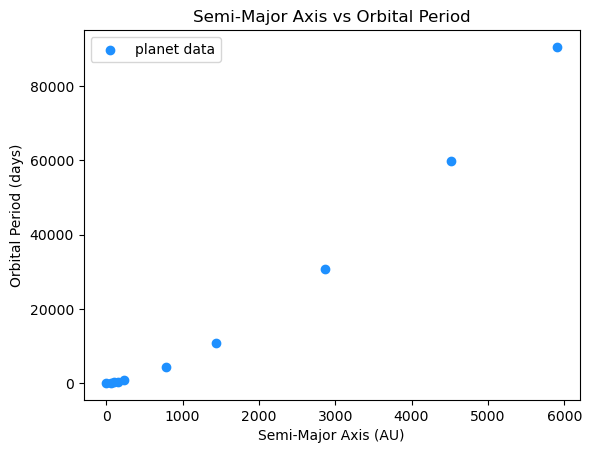

In [37]:
plt.scatter(semi_major_axis, orbital_period, color = "dodgerblue", label = "planet data")
plt.ylabel("Orbital Period (days)")
plt.xlabel("Semi-Major Axis (AU)")
plt.title("Semi-Major Axis vs Orbital Period")
plt.legend()
plt.show()
# went back in and switched order of plotting since I'm used to doing "y vs x" for titles but looks like you wanted x vs y

In [33]:
def keplers_third_law(a, m):
    return m * a ** 1.5

In [36]:
popt, pcov = curve_fit(keplers_third_law, semi_major_axis, orbital_period)
m_fit = popt[0] # only one parameter (no b_fit here)... likely NOT gonna be linear either
print(f"Best Fit Parameter: \n{m_fit:.2f}")
print(f"Fitted Model: T = {m_fit:.2f} * a^(1.50)")
# T and a from the example on the HW directions, since more m variables are confusing 

Best Fit Parameter: 
0.20
Fitted Model: T = 0.20 * a^(1.50)


In [39]:
residuals = orbital_period - keplers_third_law(semi_major_axis, m_fit)
chi2 = np.sum(residuals**2)
dof = len(orbital_period) - len(popt)
chi2_reduced = chi2 / dof
print(f"Reduced chi-squared: \n{chi2_reduced:.2f}")

Reduced chi-squared: 
41276.71


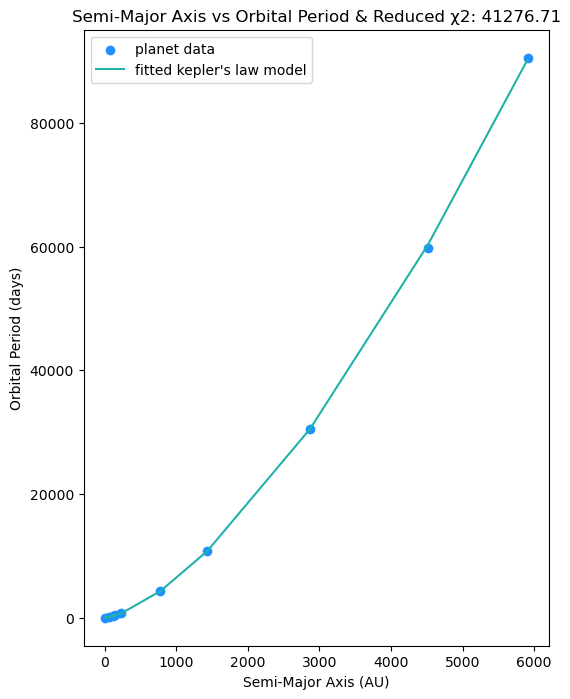

In [40]:
plt.figure(figsize = (6,8))
plt.scatter(semi_major_axis, orbital_period, color = "dodgerblue", label = "planet data")
plt.plot(semi_major_axis, keplers_third_law(semi_major_axis, m_fit), color = "lightseagreen", label = "fitted kepler's law model")
plt.title(f"Semi-Major Axis vs Orbital Period & Reduced χ2: {chi2_reduced:.2f}")
plt.ylabel("Orbital Period (days)")
plt.xlabel("Semi-Major Axis (AU)")
plt.legend()
plt.show()

In [41]:
# was a little bit confused about what new dataframe to save, hopefully it is just this new appended one renamed,
# and not one with the chi2 like before (that would be a very boring dataframe as there isn't stuff to very like the noise exercise)
# so hopefully this is what you meant by new dataframe?
solar_system.to_csv("kepler.csv", index=False) # did this like before, apparently this removes the extra fake unnamed column of the row numbers

Done with this notebook!